In [22]:
import pandas as pd

import matplotlib.pyplot as plt

import folium
from branca.colormap import linear

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [23]:
# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
del housing

In [24]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


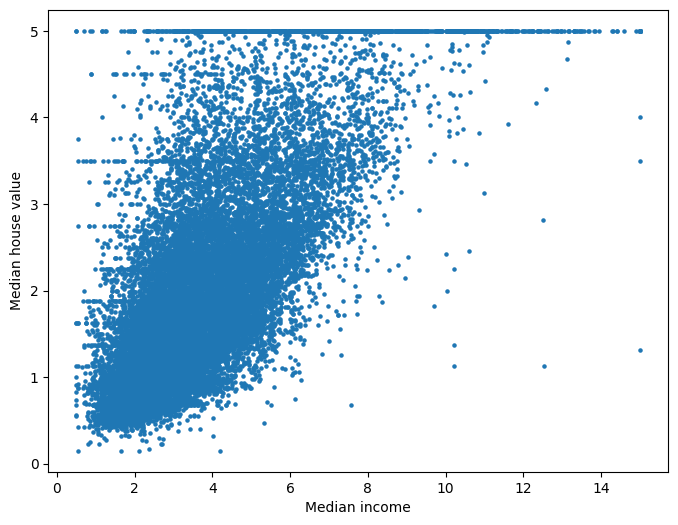

In [25]:
# Scattter plot showing correlations
plt.figure(figsize=(8,6))
plt.scatter(
    df["MedInc"], 
    df["MedHouseVal"],
    s=5
)
plt.xlabel("Median income")
plt.ylabel("Median house value")
plt.show()

In [26]:
# Simple linear reg ML model
X = df.drop(columns = "MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)


In [27]:
# RF ML model, show interactive map
model_rf = RandomForestRegressor(
    n_estimators=200, random_state=42, n_jobs=-1
)
model_rf.fit(X_train, y_train)

# 3) Predict on test set (nice for honest evaluation)
test = X_test.copy()
test["actual"] = y_test
test["pred"] = model_rf.predict(X_test)
test["residual"] = test["actual"] - test["pred"]

print("R²:", r2_score(test["actual"], test["pred"]))

# 4) Sample points so the map stays fast (tweak as you like)
plot_df = test.sample(n=min(3000, len(test)), random_state=42).copy()

# 5) Create folium map centered on the sample
center = [plot_df["Latitude"].mean(), plot_df["Longitude"].mean()]
m = folium.Map(location=center, zoom_start=6, tiles="CartoDB positron")

# Choose what to colour by: "pred" or "residual"
color_by = "pred"  # change to "residual" to map errors instead

vmin, vmax = plot_df[color_by].min(), plot_df[color_by].max()
cmap = linear.viridis.scale(vmin, vmax)
cmap.caption = f"{color_by} (MedHouseVal in $100k units)" if color_by == "pred" else "Residual (actual - pred)"

# Layer: predicted values (or residuals)
fg = folium.FeatureGroup(name=f"Points coloured by {color_by}", show=True)

for _, r in plot_df.iterrows():
    val = float(r[color_by])
    folium.CircleMarker(
        location=[float(r["Latitude"]), float(r["Longitude"])],
        radius=3,
        weight=0,
        fill=True,
        fill_opacity=0.7,
        color=cmap(val),
        fill_color=cmap(val),
        tooltip=(
            f"Pred: {r['pred']:.2f} ($100k)<br>"
            f"Actual: {r['actual']:.2f} ($100k)<br>"
            f"Residual: {r['residual']:.2f}"
        ),
    ).add_to(fg)

fg.add_to(m)
cmap.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)



R²: 0.8061857564039718


In [ ]:
m.show_in_browser()

In [ ]:

# 6) Save
m.save("california_predictions_map.html")
print("Saved: california_predictions_map.html (open in a browser)")